# Chapter 12 — The ML Pipeline: Validation & Leakage

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch12_validation_leakage.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch12_validation_leakage.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch12_validation_leakage.ipynb)

> **Motivating question.** How do we know a 90%-accurate sleep scorer isn't fooling us — and will it work on a patient it has never seen?

## What this notebook demonstrates

- Train/val/test, bias–variance, and overfitting
- Subject-independent validation: LOSO / GroupKFold
- The six canonical data-leakage failures and their fixes
- Class imbalance; kappa, macro-F1, balanced accuracy
- Calibration, abstention, and 'labels are measurements too'

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                             confusion_matrix)

CH = 12

STAGES = ["W", "N1", "N2", "N3", "REM"]
_MEANS = np.array([
    [2.2, 0.0, 0.0, 0.0, 1.0, 0.0],   # W
    [1.2, 1.0, 0.0, 0.0, 0.6, 0.0],   # N1 (overlaps neighbours)
    [0.0, 1.6, 1.0, 0.0, 0.0, 0.0],   # N2
    [-0.8, 0.0, 2.4, 1.0, 0.0, 0.0],  # N3 (high delta)
    [0.8, 1.0, 0.0, 0.0, 1.8, 1.0],   # REM
])


def make_subject(n_epochs, seed, subject_shift, extra_dims):
    """One subject: 5-class features + a strong subject-specific signature.

    The class signal is deliberately modest and the between-subject nuisance
    is large, so a nearest neighbour from the SAME subject (naive split) can
    'recognise the night' and inflate accuracy, while LOSO cannot.
    """
    rng = np.random.default_rng(seed)
    prior = np.array([0.10, 0.07, 0.45, 0.18, 0.20])   # N2-dominant imbalance
    y = rng.choice(5, size=n_epochs, p=prior)
    # weak-ish class signal buried in noise
    X = _MEANS[y] + rng.normal(0, 1.6, size=(n_epochs, 6))
    X = X + subject_shift[None, :]                       # per-subject offset
    # extra "nuisance" features that carry NO class info but a strong,
    # tight subject fingerprint -> a same-subject neighbour is easy to match
    fingerprint = extra_dims[None, :] + rng.normal(0, 0.25, size=(n_epochs, 4))
    return np.hstack([X, fingerprint]), y


def build_cohort(n_subjects=8, n_epochs=200, seed=0):
    rng = np.random.default_rng(seed)
    Xs, ys, gs = [], [], []
    for s in range(n_subjects):
        shift = rng.normal(0, 2.5, size=6)      # large between-subject variability
        extra = rng.normal(0, 3.0, size=4)      # distinctive subject fingerprint
        X, y = make_subject(n_epochs, seed=1000 + s,
                            subject_shift=shift, extra_dims=extra)
        Xs.append(X); ys.append(y); gs.append(np.full(n_epochs, s))
    return np.vstack(Xs), np.concatenate(ys), np.concatenate(gs)

## 12.1  bias variance

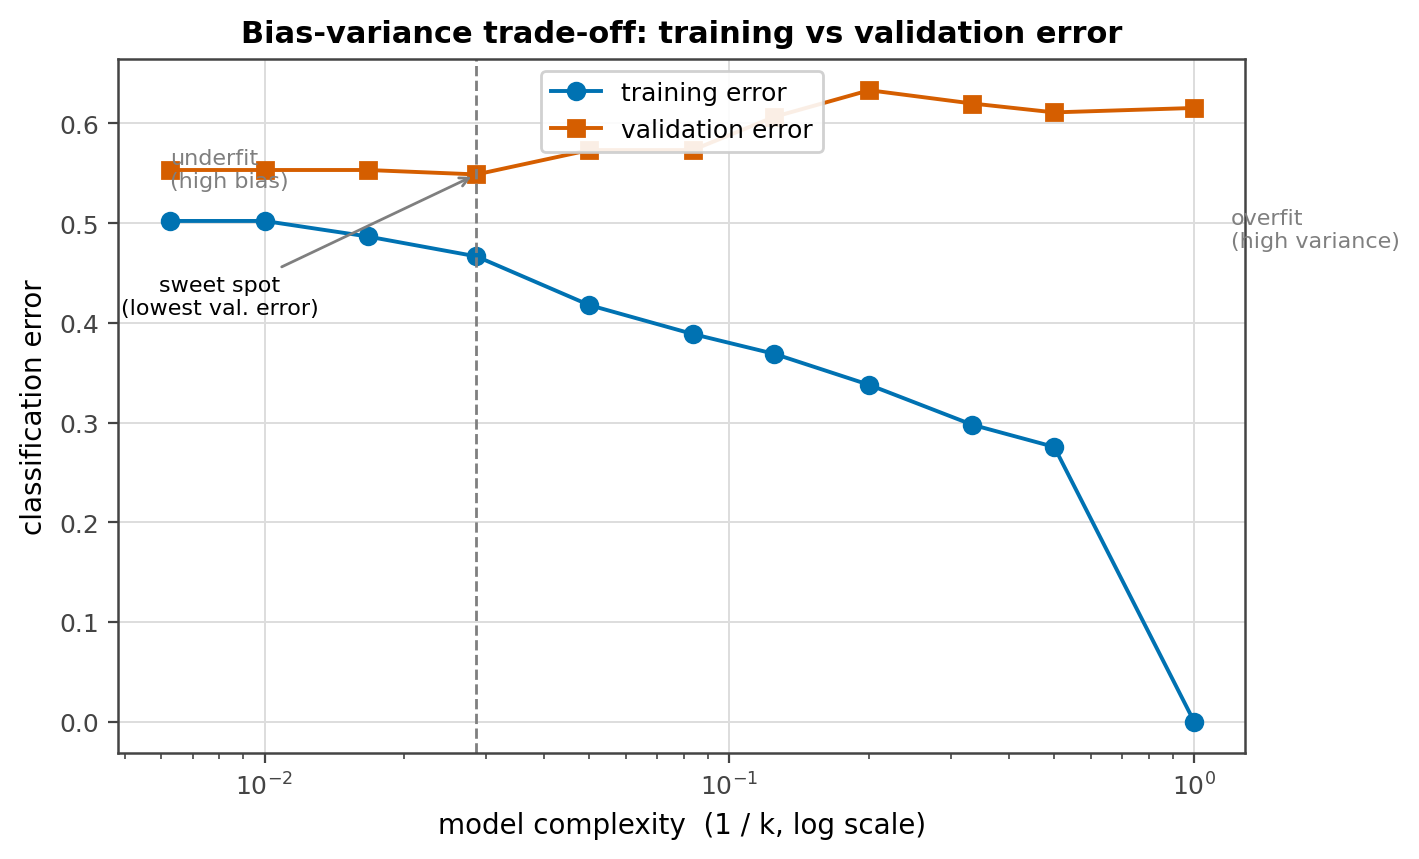

In [3]:
X, y, groups = build_cohort(n_subjects=6, n_epochs=150, seed=1)
# Split by SUBJECT, not epoch: this chapter's cohort deliberately bakes in
# a strong per-subject fingerprint (used again in fig_leakage below), so a
# plain epoch-level train_test_split would let the "sweet spot" this figure
# shows be a leakage artifact rather than genuine bias-variance behaviour --
# an awkward thing for the opening figure of the leakage chapter to teach.
tr_idx, te_idx = next(GroupShuffleSplit(test_size=0.4, random_state=0)
                      .split(X, y, groups))
Xtr, Xte, ytr, yte = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
sc = StandardScaler().fit(Xtr)
Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)

ks = [1, 2, 3, 5, 8, 12, 20, 35, 60, 100, 160]
tr_err, va_err = [], []
for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    tr_err.append(1 - clf.score(Xtr, ytr))
    va_err.append(1 - clf.score(Xte, yte))
complexity = [1.0 / k for k in ks]   # high k = low complexity

fig, ax = bs.newfig(w=7.2, h=4.4)
ax.plot(complexity, tr_err, "o-", color=bs.C["blue"], label="training error")
ax.plot(complexity, va_err, "s-", color=bs.C["red"], label="validation error")
best = int(np.argmin(va_err))
ax.axvline(complexity[best], color=bs.C["grey"], ls="--", lw=1.0)
ax.annotate("sweet spot\n(lowest val. error)",
            xy=(complexity[best], va_err[best]),
            xytext=(complexity[best] * 0.28, va_err[best] - 0.14),
            arrowprops=dict(arrowstyle="->", color=bs.C["grey"]),
            fontsize=8, ha="center")
ax.text(complexity[-1], tr_err[-1] + 0.03, "underfit\n(high bias)",
        fontsize=8, ha="left", va="bottom", color=bs.C["grey"])
ax.text(complexity[0] * 1.2, va_err[0] - 0.10, "overfit\n(high variance)",
        fontsize=8, ha="left", va="top", color=bs.C["grey"])
ax.set_xscale("log")
ax.set_xlabel("model complexity  (1 / k, log scale)")
ax.set_ylabel("classification error")
ax.set_title("Bias-variance trade-off: training vs validation error")
ax.legend(loc="upper center", fontsize=9)
plt.tight_layout()
plt.show()

## 12.2  leakage

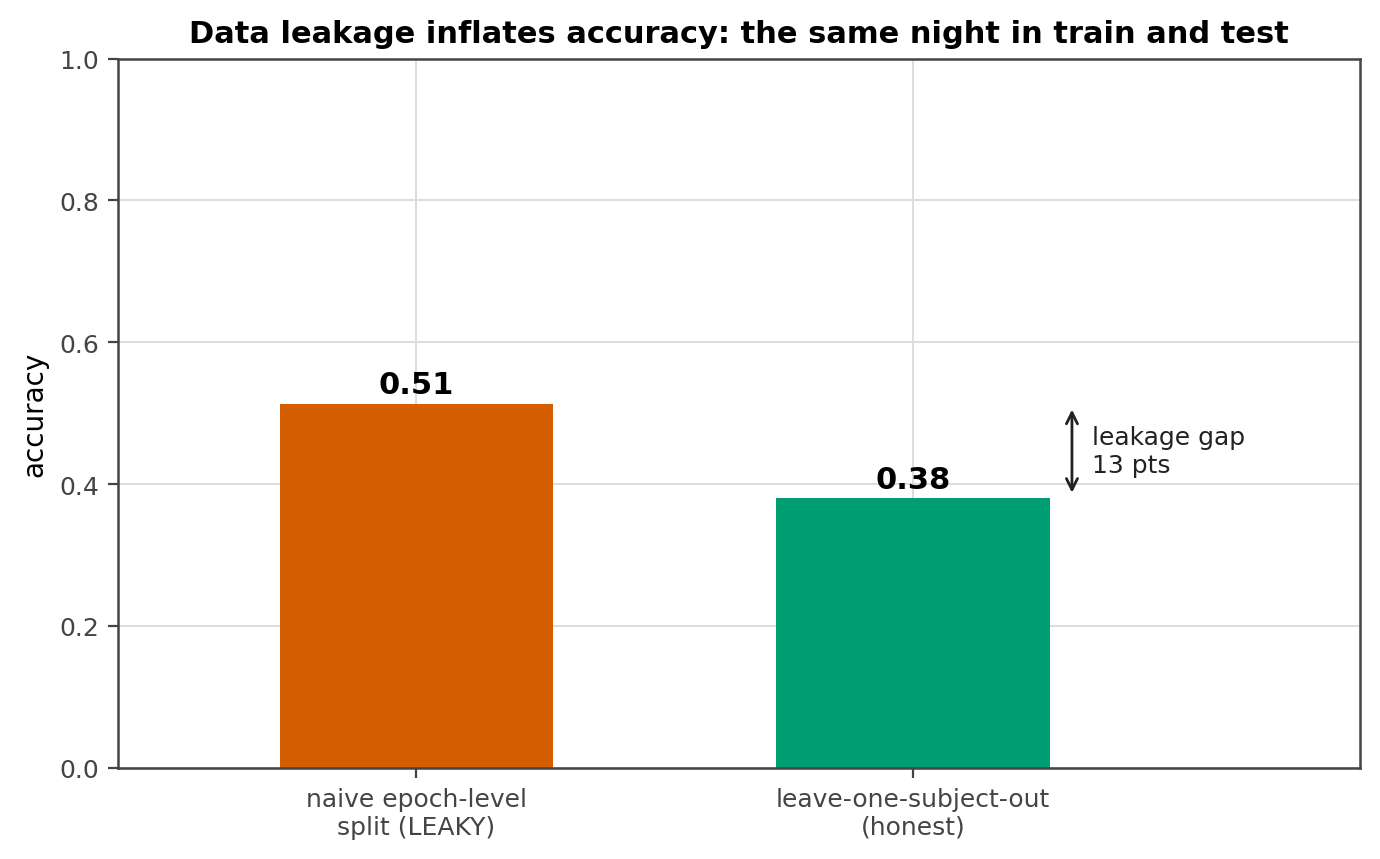

In [4]:
X, y, groups = build_cohort(n_subjects=8, n_epochs=200, seed=2)

# --- naive: random epoch-level split (same subject in train AND test) ---
naive_accs = []
for rs in range(10):
    Xtr, Xte, ytr, yte, gtr, gte = train_test_split(
        X, y, groups, test_size=0.3, random_state=rs, stratify=y)
    sc = StandardScaler().fit(Xtr)
    clf = KNeighborsClassifier(n_neighbors=5).fit(sc.transform(Xtr), ytr)
    naive_accs.append(accuracy_score(yte, clf.predict(sc.transform(Xte))))
naive = np.mean(naive_accs)

# --- honest: leave-one-subject-out ---
logo = LeaveOneGroupOut()
loso_accs = []
for tr, te in logo.split(X, y, groups):
    sc = StandardScaler().fit(X[tr])
    clf = KNeighborsClassifier(n_neighbors=5).fit(sc.transform(X[tr]), y[tr])
    loso_accs.append(accuracy_score(y[te], clf.predict(sc.transform(X[te]))))
loso = np.mean(loso_accs)

fig, ax = bs.newfig(w=7.0, h=4.4)
bars = ax.bar(["naive epoch-level\nsplit (LEAKY)", "leave-one-subject-out\n(honest)"],
              [naive, loso], color=[bs.C["red"], bs.C["green"]], width=0.55)
for b, v in zip(bars, [naive, loso]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}",
            ha="center", fontsize=11, fontweight="bold")
ax.annotate("", xy=(1.32, naive), xytext=(1.32, loso),
            arrowprops=dict(arrowstyle="<->", color=bs.C["black"]))
ax.text(1.36, (naive + loso) / 2, f"leakage gap\n{(naive - loso) * 100:.0f} pts",
        fontsize=9, va="center", color=bs.C["black"])
ax.set_xlim(-0.6, 1.9)
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1.0)
ax.set_title("Data leakage inflates accuracy: the same night in train and test")
plt.tight_layout()
plt.show()

## 12.3  confusion

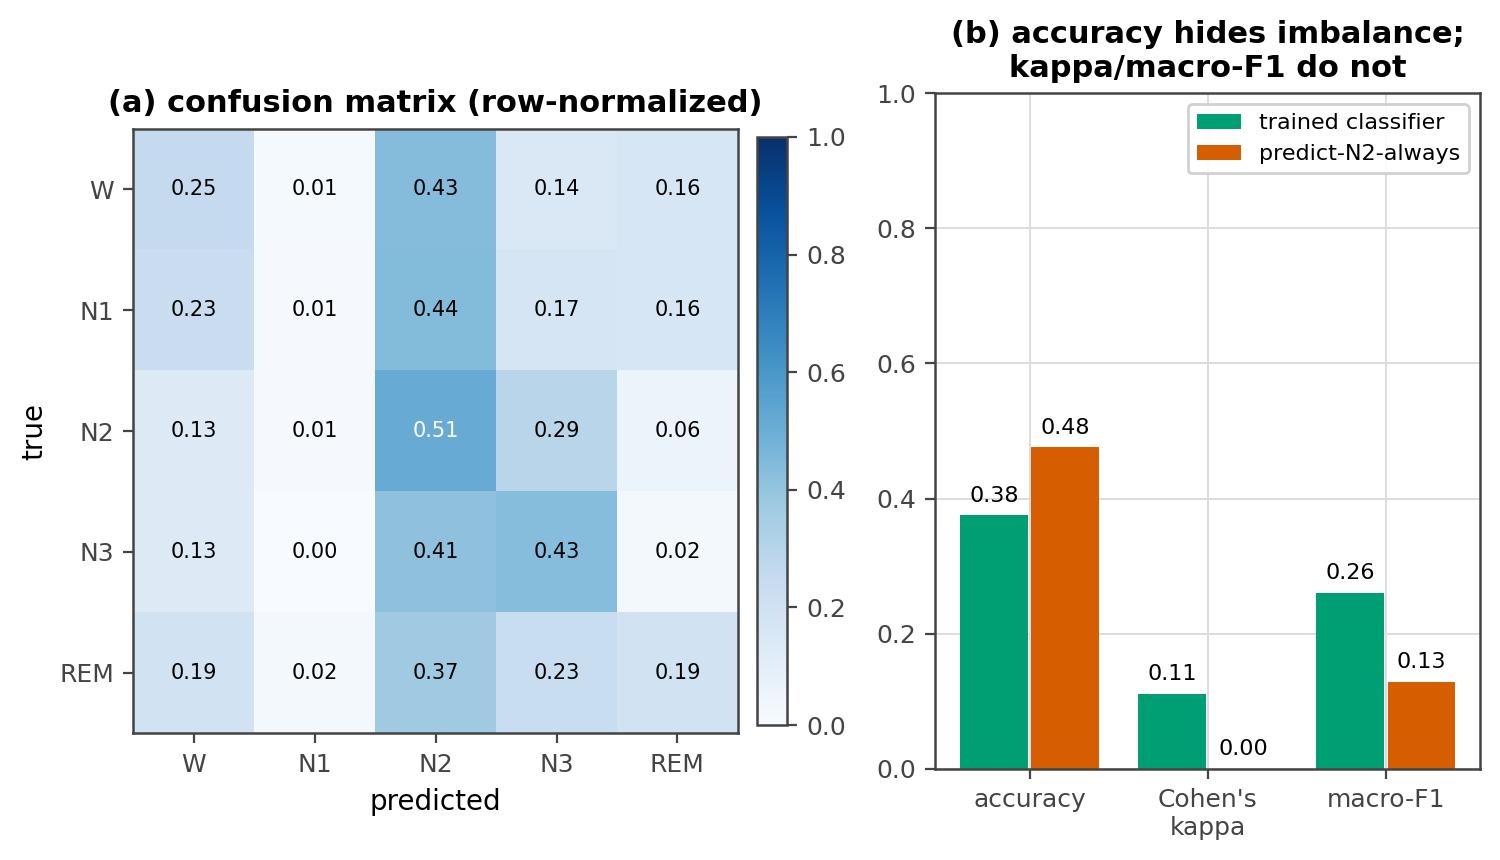

In [5]:
X, y, groups = build_cohort(n_subjects=8, n_epochs=200, seed=3)
# honest LOSO predictions pooled
logo = LeaveOneGroupOut()
y_true_all, y_pred_all = [], []
for tr, te in logo.split(X, y, groups):
    sc = StandardScaler().fit(X[tr])
    clf = KNeighborsClassifier(n_neighbors=7).fit(sc.transform(X[tr]), y[tr])
    y_true_all.append(y[te])
    y_pred_all.append(clf.predict(sc.transform(X[te])))
yt = np.concatenate(y_true_all)
yp = np.concatenate(y_pred_all)

cm = confusion_matrix(yt, yp)
cmn = cm / cm.sum(axis=1, keepdims=True)

acc = accuracy_score(yt, yp)
kappa = cohen_kappa_score(yt, yp)
mf1 = f1_score(yt, yp, average="macro")

# a "majority-class" baseline that ONLY predicts N2
maj = np.full_like(yt, 2)
acc_maj = accuracy_score(yt, maj)
kappa_maj = cohen_kappa_score(yt, maj)
mf1_maj = f1_score(yt, maj, average="macro")

fig, ax = bs.newfig(w=7.6, h=4.4, nrows=1, ncols=2,
                    gridspec_kw={"width_ratios": [1.2, 1.0]})

im = ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(STAGES)
ax[0].set_yticks(range(5)); ax[0].set_yticklabels(STAGES)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
ax[0].set_title("(a) confusion matrix (row-normalized)")
ax[0].grid(False)
for i in range(5):
    for j in range(5):
        ax[0].text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                   fontsize=7.5,
                   color="white" if cmn[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax[0], fraction=0.045, pad=0.03)

xlab = ["accuracy", "Cohen's\nkappa", "macro-F1"]
xpos = np.arange(3)
ax[1].bar(xpos - 0.2, [acc, kappa, mf1], width=0.38,
          color=bs.C["green"], label="trained classifier")
ax[1].bar(xpos + 0.2, [acc_maj, kappa_maj, mf1_maj], width=0.38,
          color=bs.C["red"], label="predict-N2-always")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(xlab)
ax[1].set_ylim(0, 1.0)
ax[1].set_title("(b) accuracy hides imbalance;\nkappa/macro-F1 do not")
ax[1].legend(loc="upper right", fontsize=8)
for xp, v in zip(xpos - 0.2, [acc, kappa, mf1]):
    ax[1].text(xp, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
for xp, v in zip(xpos + 0.2, [acc_maj, kappa_maj, mf1_maj]):
    ax[1].text(xp, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 12.4  roc pr

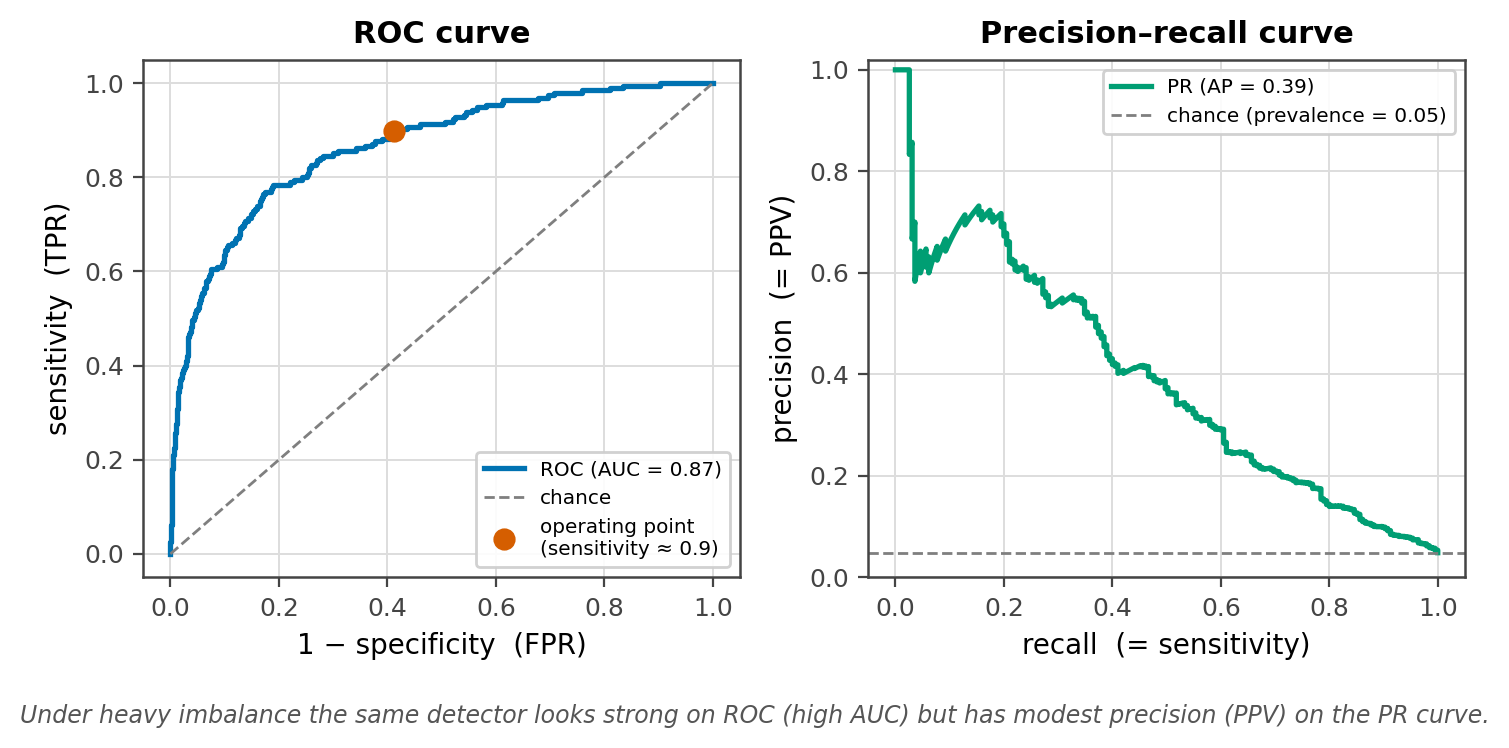

In [6]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score)
r = np.random.default_rng(42)
n = 4000
y = (r.random(n) < 0.05).astype(int)               # ~5% positives (rare event)
scores = r.standard_normal(n) + 1.7 * y             # overlapping detector score
fpr, tpr, _ = roc_curve(y, scores); roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y, scores)
ap = average_precision_score(y, scores)
idx = int(np.argmin(np.abs(tpr - 0.90)))
fig, ax = bs.newfig(w=7.4, h=3.5, nrows=1, ncols=2)
ax[0].plot(fpr, tpr, color=bs.C["blue"], lw=1.9, label=f"ROC (AUC = {roc_auc:.2f})")
ax[0].plot([0, 1], [0, 1], "--", color=bs.C["grey"], lw=1.0, label="chance")
ax[0].plot(fpr[idx], tpr[idx], "o", color=bs.C["red"], ms=7,
           label="operating point\n(sensitivity ≈ 0.9)")
ax[0].set_xlabel("1 − specificity  (FPR)"); ax[0].set_ylabel("sensitivity  (TPR)")
ax[0].set_title("ROC curve"); ax[0].legend(loc="lower right", fontsize=7.2)
ax[1].plot(rec, prec, color=bs.C["green"], lw=1.9, label=f"PR (AP = {ap:.2f})")
ax[1].axhline(y.mean(), ls="--", color=bs.C["grey"], lw=1.0,
              label=f"chance (prevalence = {y.mean():.2f})")
ax[1].set_xlabel("recall  (= sensitivity)"); ax[1].set_ylabel("precision  (= PPV)")
ax[1].set_title("Precision–recall curve"); ax[1].set_ylim(0, 1.02)
ax[1].legend(loc="upper right", fontsize=7.2)
bs.takeaway(fig, "Under heavy imbalance the same detector looks strong on ROC (high AUC) "
                 "but has modest precision (PPV) on the PR curve.")
plt.tight_layout()
plt.show()

## 12.5  ppv npv vs prevalence

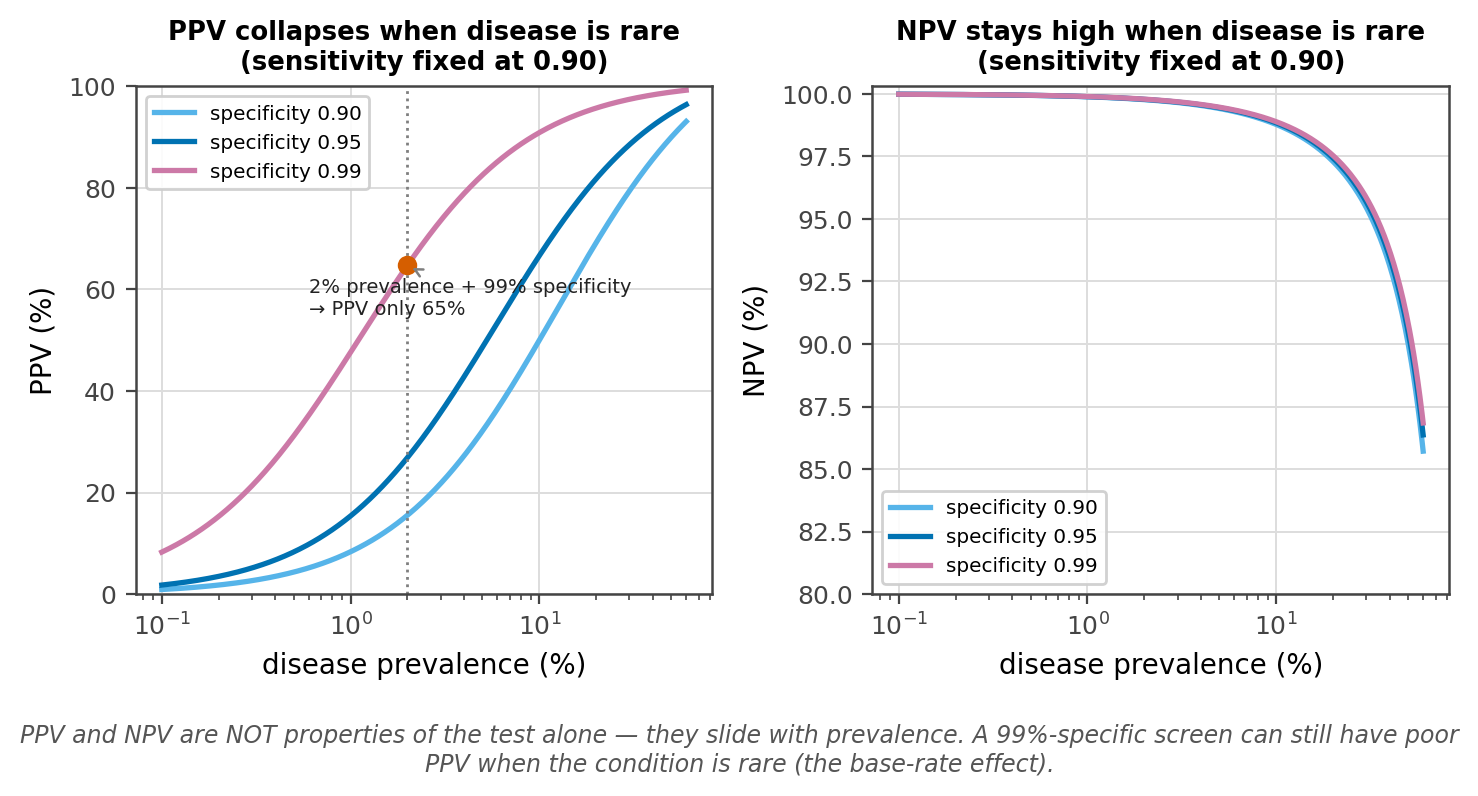

In [7]:
# Sensitivity and specificity are properties of the TEST; PPV and NPV also
# depend on how common the condition is (the base rate). Bayes' rule made visible.
prev = np.logspace(-3, np.log10(0.6), 500)          # 0.1% .. 60% prevalence
sens = 0.90                                          # fix the test characteristics
def ppv(spec, p): return sens * p / (sens * p + (1 - spec) * (1 - p))
def npv(spec, p): return spec * (1 - p) / (spec * (1 - p) + (1 - sens) * p)

fig, ax = bs.newfig(w=7.4, h=3.6, nrows=1, ncols=2)
specs = [0.90, 0.95, 0.99]
cols = [bs.C["sky"], bs.C["blue"], bs.C["purple"]]
for spec, c in zip(specs, cols):
    ax[0].plot(prev * 100, ppv(spec, prev) * 100, color=c, lw=1.9, label=f"specificity {spec:.2f}")
    ax[1].plot(prev * 100, npv(spec, prev) * 100, color=c, lw=1.9, label=f"specificity {spec:.2f}")
# annotate the classic screening trap at 2% prevalence, 99% specificity
p0 = 0.02
ax[0].axvline(p0 * 100, color=bs.C["grey"], ls=":", lw=1.0)
ax[0].plot(p0 * 100, ppv(0.99, p0) * 100, "o", color=bs.C["red"], ms=6)
ax[0].annotate(f"2% prevalence + 99% specificity\n→ PPV only {ppv(0.99, p0)*100:.0f}%",
               xy=(p0 * 100, ppv(0.99, p0) * 100), xytext=(0.30, 0.55),
               textcoords="axes fraction", fontsize=7.0, color=bs.C["black"],
               arrowprops=dict(arrowstyle="->", color=bs.C["grey"], lw=0.9))
ax[0].set_xscale("log"); ax[0].set_xlabel("disease prevalence (%)"); ax[0].set_ylabel("PPV (%)")
ax[0].set_title(f"PPV collapses when disease is rare\n(sensitivity fixed at {sens:.2f})", fontsize=9.3)
ax[0].set_ylim(0, 100); ax[0].legend(loc="upper left", fontsize=7.2)
ax[1].set_xscale("log"); ax[1].set_xlabel("disease prevalence (%)"); ax[1].set_ylabel("NPV (%)")
ax[1].set_title(f"NPV stays high when disease is rare\n(sensitivity fixed at {sens:.2f})", fontsize=9.3)
ax[1].set_ylim(80, 100.3); ax[1].legend(loc="lower left", fontsize=7.2)
bs.takeaway(fig, "PPV and NPV are NOT properties of the test alone — they slide with prevalence. "
                 "A 99%-specific screen can still have poor PPV when the condition is rare (the base-rate effect).")
plt.tight_layout()
plt.show()

## 12.6  calibration abstention

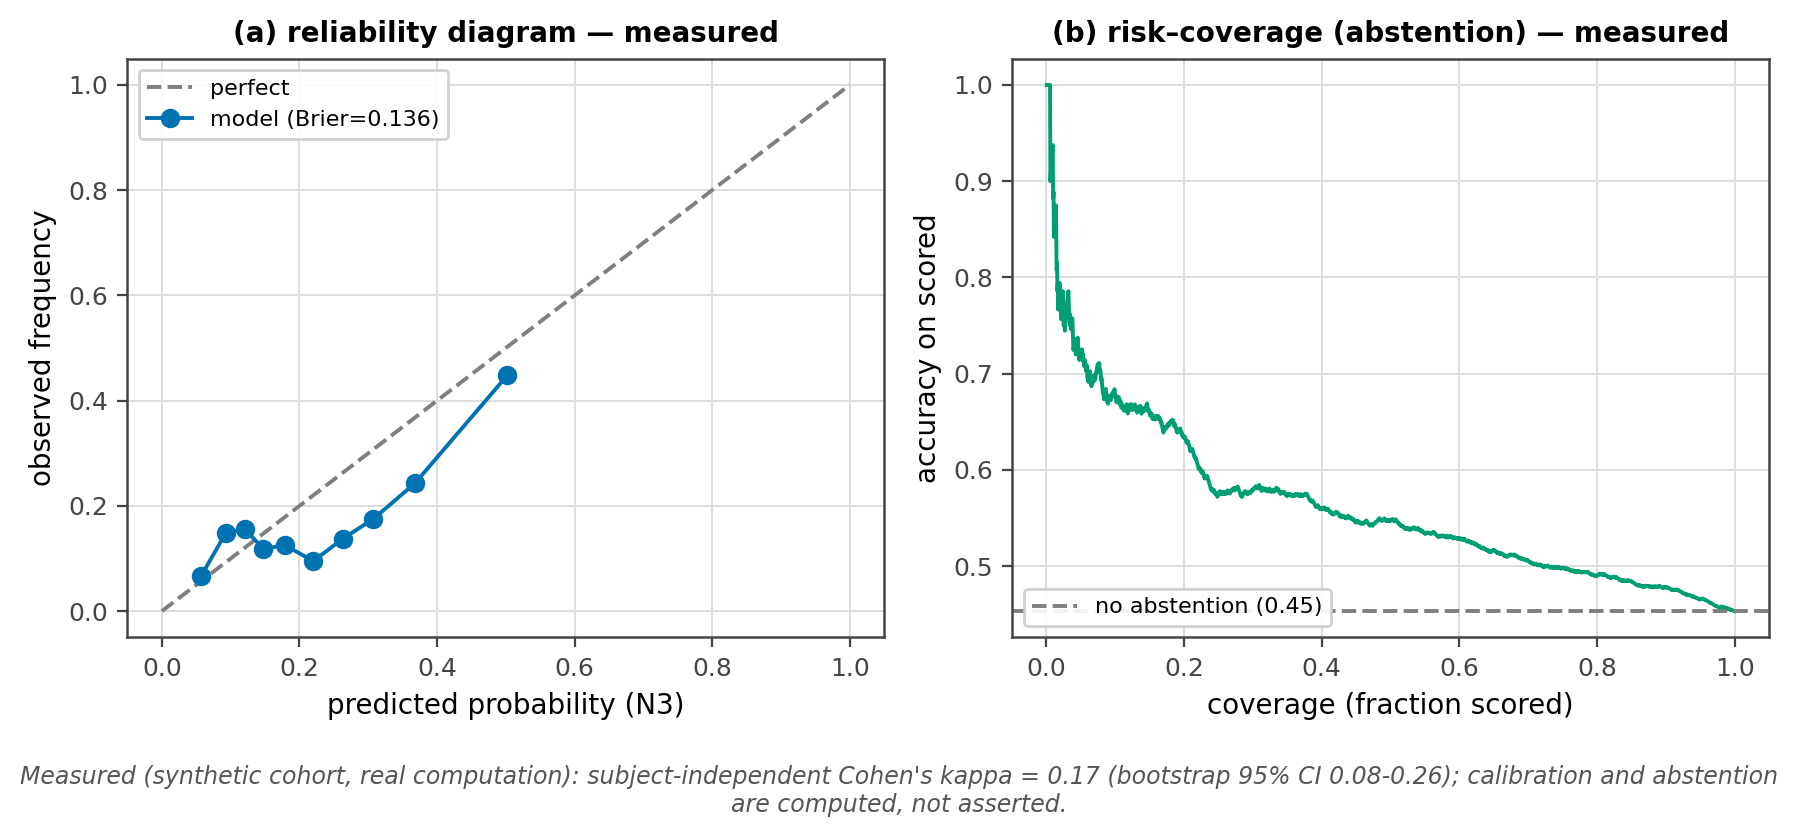

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
X, y, groups = build_cohort(n_subjects=8, n_epochs=220, seed=3)
cv = GroupKFold(5)
clf = RandomForestClassifier(250, random_state=0)
proba = cross_val_predict(clf, X, y, cv=cv, groups=groups, method="predict_proba")
pred = proba.argmax(1)

fig, ax = bs.newfig(w=9.0, h=3.8, ncols=2)
# (a) reliability diagram for a one-vs-rest detector (N3 = index 3)
cls = STAGES.index("N3"); p_cls = proba[:, cls]; y_cls = (y == cls).astype(int)
frac, mean_pred = calibration_curve(y_cls, p_cls, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_cls, p_cls)
ax[0].plot([0, 1], [0, 1], ls="--", color=bs.C["grey"], label="perfect")
ax[0].plot(mean_pred, frac, "o-", color=bs.C["blue"], label=f"model (Brier={brier:.3f})")
ax[0].set_xlabel("predicted probability (N3)"); ax[0].set_ylabel("observed frequency")
ax[0].set_title("(a) reliability diagram — measured", fontsize=10)
ax[0].legend(loc="upper left", fontsize=8)

# (b) risk-coverage: abstain on low max-probability, plot accuracy vs coverage
conf = proba.max(1); order = np.argsort(-conf)
correct = (pred == y)[order]
cov = np.arange(1, len(y) + 1) / len(y)
acc_at_cov = np.cumsum(correct) / np.arange(1, len(y) + 1)
ax[1].plot(cov, acc_at_cov, color=bs.C["green"])
ax[1].axhline(correct.mean(), ls="--", color=bs.C["grey"],
              label=f"no abstention ({correct.mean():.2f})")
ax[1].set_xlabel("coverage (fraction scored)"); ax[1].set_ylabel("accuracy on scored")
ax[1].set_title("(b) risk–coverage (abstention) — measured", fontsize=10)
ax[1].legend(loc="lower left", fontsize=8)

# bootstrap 95% CI for multiclass kappa — resample SUBJECTS with replacement
# (not epochs), matching §12.7: epochs within a subject are not independent, so
# an epoch-level bootstrap understates the true (subject-driven) uncertainty.
rng = np.random.default_rng(0)
subs = np.unique(groups)
by_sub = {s: np.where(groups == s)[0] for s in subs}
ks = []
for _ in range(1000):
    pick = rng.choice(subs, size=len(subs), replace=True)
    idx = np.concatenate([by_sub[s] for s in pick])
    ks.append(cohen_kappa_score(y[idx], pred[idx]))
lo, hi = np.percentile(ks, [2.5, 97.5])
bs.takeaway(fig, f"Measured (synthetic cohort, real computation): subject-independent "
                 f"Cohen's kappa = {cohen_kappa_score(y, pred):.2f} (bootstrap 95% CI "
                 f"{lo:.2f}-{hi:.2f}); calibration and abstention are computed, not asserted.",
            y=-0.02)
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above and the numbers below *exactly* — the cell below **asserts** them with `expect_close`, so a broken environment is flagged rather than failing silently.

In [9]:
from bsp.metrics import (alias_frequency, quantization_snr_db, sqrtN_gain_db,
                         snr_db, cohens_kappa, macro_f1)
from bsp.notebook_checks import expect_close, expected_output_table
from IPython.display import Markdown, display
_rows = []
_rows.append(expect_close("Cohen's kappa, perfect agreement", cohens_kappa([0,1,2,3,4],[0,1,2,3,4]), 1.0, 0.001, 'abs'))
_rows.append(expect_close("Cohen's kappa, constant-guess baseline", cohens_kappa([0,1,0,2,1,2],[0,0,0,0,0,0]), 0.0, 0.001, 'abs'))
display(Markdown(expected_output_table(_rows)))

[PASS] Cohen's kappa, perfect agreement: got 1, expected 1 (abs)
[PASS] Cohen's kappa, constant-guess baseline: got 0, expected 0 (abs)


| Quantity | Got | Expected | Status |
|---|---:|---:|:--:|
| Cohen's kappa, perfect agreement | 1 | 1 | ✅ |
| Cohen's kappa, constant-guess baseline | 0 | 0 | ✅ |

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `cvpartition` with groups; `confusionmat`; `kappa` (custom).

## Leakage-safety checklist

Any ML step in this notebook must obey:

- no scaling or feature selection **before** the split;
- no epoch-level random split when claiming new-subject generalisation (use LOSO / GroupKFold);
- every reported metric states its split unit (epoch, subject, night);
- synthetic performance is labelled *illustrative*, never clinical.

In [10]:
from bsp.notebook_checks import assert_no_subject_leak
# Example guard used throughout the pipeline notebooks:
# assert_no_subject_leak(groups[train_idx], groups[test_idx])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Measure the inflated accuracy of an epoch-level split vs an honest LOSO split.

<details><summary>💡 Hint &amp; what you should see</summary>

A random epoch split puts a subject's epochs in **both** train and test → the model memorises the person, inflating accuracy. LOSO is honest and lower — **the gap is the leak**.

</details>

**2.** Assert no subject appears in both train and test.

<details><summary>💡 Hint &amp; what you should see</summary>

`assert_no_subject_leak(groups[train], groups[test])` fails loudly on overlap. Run it on the leaky split to watch it **fire**, then on the LOSO split to watch it **pass**.

</details>

In [11]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch12_figures.py`.*